In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 54.5 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
!unzip "/content/drive/MyDrive/archive (1).zip" -d "/content/WasteProject"

Archive:  /content/drive/MyDrive/archive (1).zip
replace /content/WasteProject/YOLO-Waste-Detection-1/YOLO-Waste-Detection-1/README.dataset.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [5]:
import os
print(os.listdir("/content/WasteProject"))

['YOLO-Waste-Detection-1', 'data.yaml', 'paper', 'paper_data.yaml']


In [8]:
# Latest weights test
!yolo task=detect mode=val model=/content/drive/MyDrive/YOLO_Waste_Training/waste_run/weights/last.pt data=/content/WasteProject/data.yaml

Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,014,228 parameters, 0 gradients, 8.1 GFLOPs

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/cfg/__init__.py", line 993, in entrypoint
    getattr(model, mode)(**overrides)  # default args from model
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 614, in val
    validator(model=self.model)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/_contextlib.py", line 124, in decorate_context
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/validator.py", line 185, in __call__
    self.data = check_det_dataset(self.args.data)
                ^^^^^^^^^^^^^^^^^^^^^^^

In [ ]:
# Latest weights test
!yolo task=detect mode=val model=/content/drive/MyDrive/YOLO_Waste_Training/waste_run/weights/last.pt data=/content/WasteProject/data.yaml

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,014,228 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1212.3±640.5 MB/s, size: 40.8 KB)
val: Scanning /content/WasteProject/YOLO-Waste-Detection-1/YOLO-Waste-Detection-1/valid/labels... 2013 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2013/2013 1.9Kit/s 1.1s
val: New cache created: /content/WasteProject/YOLO-Waste-Detection-1/YOLO-Waste-Detection-1/valid/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 5, len(boxes) = 2970. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 126/126 5.2s/it 10:53
                   all       2013       2970      0.527      

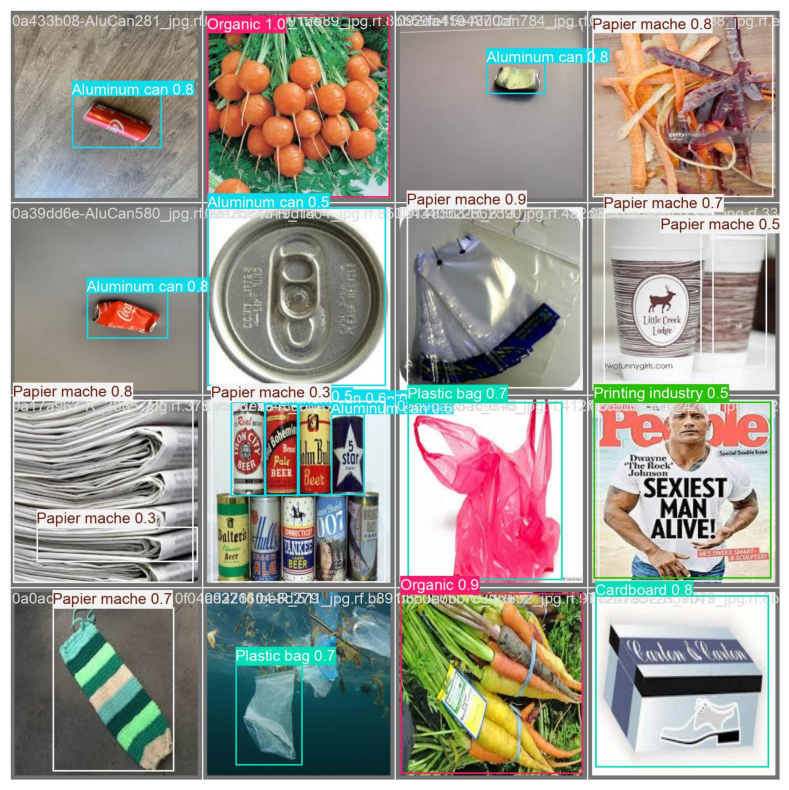

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

path = '/content/runs/detect/val2/'
images = [f for f in os.listdir(path) if f.endswith('.jpg')]

if images:
    img = mpimg.imread(os.path.join(path, images[0]))
    plt.figure(figsize=(15,10))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [ ]:
from ultralytics import YOLO
import os

save_path = '/content/drive/MyDrive/YOLO_Waste_Training'
if not os.path.exists(save_path):
    os.makedirs(save_path)

# 3. Model load
model = YOLO('yolov8n.pt')

# 4. Training
model.train(
    data='/content/WasteProject/data.yaml',
    epochs=50,
    imgsz=640,
    device=0,
    project=save_path,    # Results will save in Drive
    name='waste_run',     # Folder name
    save_period=5,        # weights save after 5 epochs
    exist_ok=True         # if folder exist then use
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/WasteProject/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=waste_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspecti

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([22])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d3bb41c4830>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048,

In [4]:
from ultralytics import YOLO

model_path = '/content/drive/MyDrive/YOLO_Waste_Training (1)/waste_run/weights/last.pt'

# 2. Model load
model = YOLO(model_path)

# 3. Resume training
results = model.train(resume=True)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


KeyboardInterrupt: 


image 1/1 /content/waste1.PNG: 640x640 1 Aluminum can, 8.6ms
Speed: 2.8ms preprocess, 8.6ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


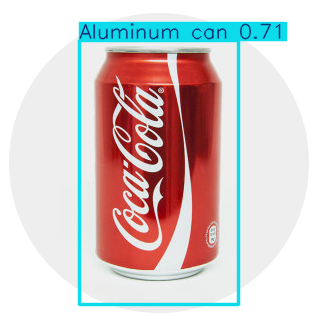

In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# 1. Best model load
model = YOLO('/content/drive/MyDrive/YOLO_Waste_Training/waste_run/weights/best.pt')

# 2. Image path
image_path = '/content/waste1.PNG'

# 3. Result
results = model.predict(source=image_path, conf=0.25, save=True)

# 4. Result show on screen
for r in results:
    im_array = r.plot()
    cv2_imshow(im_array) # Display result


image 1/1 /content/waste4.PNG: 448x640 1 Cardboard, 9.4ms
Speed: 4.5ms preprocess, 9.4ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict5


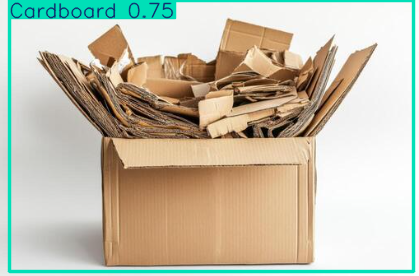

In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

model = YOLO('/content/drive/MyDrive/YOLO_Waste_Training/waste_run/weights/best.pt')

image_path = '/content/waste4.PNG'

results = model.predict(source=image_path, conf=0.10, save=True)

for r in results:
    im_array = r.plot()
    cv2_imshow(im_array)

In [5]:
from ultralytics import YOLO

# Best model load
model = YOLO('/content/drive/MyDrive/YOLO_Waste_Training/waste_run/weights/best.pt')

# Export in TensorFlow.js (web) format
model.export(format='tfjs')

Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,014,228 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/YOLO_Waste_Training/waste_run/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 48, 8400) (6.0 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx>=1.12.0,<2.0.0', 'onnx2tf>=1.26.3,<1.29.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 18 packages in 2.06s
Prepared 9 packages in 1.87s
Installed 9 packages in 476ms
 + ai-edge-litert==2.1.3
 + backports-strenum==1.3.1
 + colorama==0.4.6
 + onnx==1.21.0
 + onnx-graphsurgeon==0.6.1
 + onnx2tf==1.28.8
 + onnxruntime=


TensorFlow.js: starting export with tensorflowjs 4.22.0...

TensorFlow.js: output node names: Identity:0
TensorFlow.js: running 'tensorflowjs_converter --input_format=tf_frozen_model  --output_node_names=Identity:0 "/content/drive/MyDrive/YOLO_Waste_Training/waste_run/weights/best.pb" "/content/drive/MyDrive/YOLO_Waste_Training/waste_run/weights/best_web_model"'
TensorFlow.js: export success ✅ 11.3s, saved as '/content/drive/MyDrive/YOLO_Waste_Training/waste_run/weights/best_web_model' (11.8 MB)

Export complete (40.9s)
Results saved to /content/drive/MyDrive/YOLO_Waste_Training/waste_run/weights
Predict:         yolo predict task=detect model=/content/drive/MyDrive/YOLO_Waste_Training/waste_run/weights/best_web_model imgsz=640 
Validate:        yolo val task=detect model=/content/drive/MyDrive/YOLO_Waste_Training/waste_run/weights/best_web_model imgsz=640 data=/content/WasteProject/data.yaml  
Visualize:       https://netron.app


'/content/drive/MyDrive/YOLO_Waste_Training/waste_run/weights/best_web_model'

In [6]:
from ultralytics import YOLO
import shutil

# 1. Load your best trained model
model_path = '/content/drive/MyDrive/YOLO_Waste_Training/waste_run/weights/best.pt'
model = YOLO(model_path)

# 2. Export to TensorFlow.js format
# This creates a folder named 'best_web_model' in your weights directory
model.export(format='tfjs')

# 3. Zip the folder for easy download to your laptop
export_path = '/content/drive/MyDrive/YOLO_Waste_Training/waste_run/weights/best_web_model'
shutil.make_archive('waste_model_web', 'zip', export_path)

print("Success! Download 'waste_model_web.zip' from the Colab files sidebar.")

Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 3,014,228 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/YOLO_Waste_Training/waste_run/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 48, 8400) (6.0 MB)

TensorFlow SavedModel: starting export with tensorflow 2.19.0...

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 1.1s, saved as '/content/drive/MyDrive/YOLO_Waste_Training/waste_run/weights/best.onnx' (11.7 MB)
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.8...
Saved artifact at '/content/drive/MyDrive/YOLO_Waste_Training/waste_run/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 48, 8400